# Polio campaign monitoring: predicting "Not Available" children

**Context.** After each polio vaccination campaign, Independent Campaign Monitoring (ICM) monitors visit
clusters of households and record every child who was missed and why. *Not Available* (**NA**:
the child was away from home when the vaccination team visited) is one of the main reasons children miss a dose.

**Goal.** For each monitor in each campaign, estimate how many NA children they *should* find, given their
workload and their history. This supports two uses:
1. **Planning:** where to expect many NA children (so teams can plan revisits).
2. **Data quality:** reports that are far from the expected value can be reviewed.

**Key points of this notebook:**
- An accounting identity in the survey means `NA` can be rebuilt exactly from other columns. Those columns are removed.
- Evaluation uses a **time-based split**: train on earlier campaigns, test on the 5 most recent ones.
- Every model is compared with a simple baseline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

import icm_model as icm

pd.set_option("display.float_format", "{:.3f}".format)
raw = icm.load_raw()
print(raw.shape)
raw.head()

(120378, 35)


,ICM_ID,MONITORID,UCID,CAMP_ID,CAMP_DAY,DAY_WORK,CLUSTER_NUMBER,TOTAL_HH,HRMP,TEAM_NUMBER,...,NT_VAC,TVBM_VAC,NA_VAC,ASLEEP_VAC,REFUSAL_VAC,OTHER_VAC,VBNFM_VAC,CORRECT_DOOR_MARK,ZERO_DOSE_023,CLUSTER_DATE
0,1,224,5191,1,1,1,1,7,1,1,...,0,0,0,0,0,0,0,7,0,2020-03-08
1,2,84,5163,1,1,1,1,7,2,4,...,0,0,0,0,0,1,0,7,0,2020-03-09
2,3,405,5167,1,1,1,1,7,2,2,...,0,0,0,0,0,0,0,7,0,2020-03-09
3,4,405,5167,1,1,1,2,7,2,1,...,0,0,0,0,0,0,0,7,0,2020-03-09
4,5,184,5112,1,1,1,1,7,2,2,...,0,0,0,0,0,0,0,7,0,2020-03-09


## 1. Data overview

One row per **cluster** checked by a monitor. The most important columns:

| Column | Meaning |
|---|---|
| `MONITORID`, `CAMP_ID`, `UCID` | monitor, campaign, union council (area) |
| `RECALL_011_CHK` / `RECALL_1259_CHK` | children aged 0-11 / 12-59 months checked |
| `*_VAC` | how many of those were vaccinated |
| `NT`, `TVBMC`, `NA`, `ASLEEP`, `REFUSAL`, `OTHER_REASON` | reasons why unvaccinated children were missed |
| `FM_059_CHK`, `GUEST_CHK` | children checked by finger-marking / guest children |

In [2]:
print("Campaigns:", raw["CAMP_ID"].nunique(), "| Monitors:", raw["MONITORID"].nunique(),
      "| Dates:", raw["CLUSTER_DATE"].min().date(), "to", raw["CLUSTER_DATE"].max().date())
print("Missing values:", int(raw.isna().sum().sum()), "| Duplicate rows:", int(raw.duplicated().sum()))

Campaigns: 34 | Monitors: 788 | Dates: 2020-03-08 to 2024-05-04
Missing values: 0 | Duplicate rows: 0


## 2. Leakage check: an accounting identity

Every unvaccinated child in the recall sample is assigned exactly one reason. So
`checked - vaccinated = NT + TVBMC + NA + ASLEEP + REFUSAL + OTHER_REASON`. If that holds, any model
given the unvaccinated counts **and** the other reasons can simply subtract its way to `NA`.

In [3]:
unvaccinated = (raw["RECALL_011_CHK"] - raw["RECALL_011_VAC"]) + (raw["RECALL_1259_CHK"] - raw["RECALL_1259_VAC"])
reasons = raw[["NT", "TVBMC", "NA", "ASLEEP", "REFUSAL", "OTHER_REASON"]].sum(axis=1)
print(f"Identity holds for {(unvaccinated == reasons).mean():.4%} of rows")

Identity holds for 99.9992% of rows


The first version of this project used features such as `RECALL_1259_CHK - RECALL_1259_VAC` together with
`REFUSAL` and a random train/test split, and reported **R² = 0.94**. The cell below shows why that number
can't be trusted: with the identity features, even a plain linear regression is essentially perfect.

In [4]:
leaky = raw.assign(unvaccinated=unvaccinated).groupby(icm.KEYS).sum(numeric_only=True)
X = leaky[["unvaccinated", "NT", "TVBMC", "ASLEEP", "REFUSAL", "OTHER_REASON"]]
X_tr, X_te, y_tr, y_te = train_test_split(X, leaky["NA"], test_size=0.2, random_state=42)
print("R² using identity features:", round(r2_score(y_te, LinearRegression().fit(X_tr, y_tr).predict(X_te)), 4))
print("Excluded as leaky:", ", ".join(icm.LEAKY_COLUMNS))

R² using identity features: 1.0
Excluded as leaky: NT, TVBMC, ASLEEP, REFUSAL, OTHER_REASON, VBNFM, RECALL_011_VAC, RECALL_1259_VAC, GUEST_VAC, FM_059_VAC, NT_VAC, TVBM_VAC, NA_VAC, ASLEEP_VAC, REFUSAL_VAC, OTHER_VAC, VBNFM_VAC


## 3. Monitor x campaign table

The cluster rows are aggregated to one row per monitor per campaign. Features:

- **Workload in this campaign:** clusters, union councils, households, children checked, finger-marked and guest children, zero-dose children, door-marking rate, share of high-risk/mobile population (HRMP) clusters.
- **History (earlier campaigns only):** the monitor's NA rate in their previous campaign and their average NA rate so far. Computed with `shift(1)`, so a campaign never sees its own target.

In [5]:
table = icm.build_monitor_campaign_table(raw)
print(table.shape)
table[icm.KEYS + ["campaign_start"] + icm.FEATURES + ["NA"]].head()

(10908, 18)


,MONITORID,CAMP_ID,campaign_start,n_clusters,n_ucs,TOTAL_HH,RECALL_011_CHK,RECALL_1259_CHK,FM_059_CHK,GUEST_CHK,ZERO_DOSE_023,door_mark_rate,hrmp_rate,prev_na_rate,hist_na_rate,n_prev_campaigns,NA
0,1,1,2020-03-09,9,1,63,27,120,106,3,4,7.000,2.000,NaN,NaN,0,13
1,2,1,2020-03-10,13,1,91,43,159,100,9,0,7.000,1.308,NaN,NaN,0,23
2,3,1,2020-03-09,19,1,133,72,265,228,12,8,6.947,2.000,NaN,NaN,0,36
3,4,1,2020-03-09,14,1,98,48,188,124,3,0,6.786,1.357,NaN,NaN,0,13
4,5,1,2020-03-09,20,1,140,67,251,160,23,3,6.400,1.450,NaN,NaN,0,27


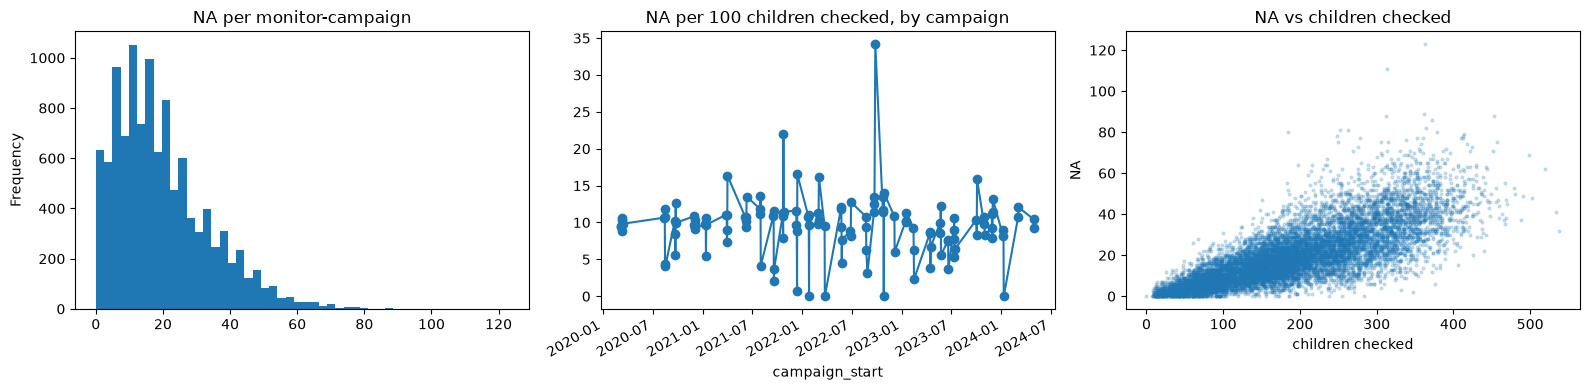

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
table["NA"].plot.hist(bins=50, ax=axes[0], title="NA per monitor-campaign")
per_campaign = table.groupby("campaign_start").apply(
    lambda d: d["NA"].sum() / (d["RECALL_011_CHK"] + d["RECALL_1259_CHK"]).sum() * 100, include_groups=False)
per_campaign.plot(marker="o", ax=axes[1], title="NA per 100 children checked, by campaign")
axes[2].scatter(table["RECALL_011_CHK"] + table["RECALL_1259_CHK"], table["NA"], s=4, alpha=0.2)
axes[2].set(title="NA vs children checked", xlabel="children checked", ylabel="NA")
plt.tight_layout()

The NA rate changes a lot from campaign to campaign, and NA grows with workload. A random row split would
put the same campaign in both train and test, so the models are tested on **future** campaigns instead.

## 4. Models on a time-based split

In [7]:
result = icm.fit_and_evaluate(table, n_test_campaigns=5)
print(f"Train: {len(result.train):,} rows ({result.train['campaign_start'].min().date()} to {result.train['campaign_start'].max().date()})")
print(f"Test:  {len(result.test):,} rows ({result.test['campaign_start'].min().date()} to {result.test['campaign_start'].max().date()})")
result.metrics

Train: 9,488 rows (2020-03-08 to 2023-10-04)
Test:  1,420 rows (2023-10-30 to 2024-04-30)


,MAE,RMSE,R2
Model,,,
Baseline (avg NA rate x children checked),6.175,8.055,0.424
Poisson GLM,5.387,6.959,0.570
Gradient boosting (Poisson),4.886,6.573,0.617


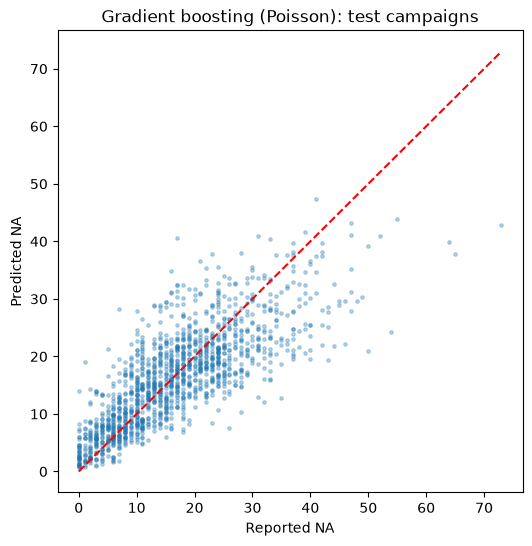

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(result.test["NA"], result.test["Predicted_NA"], s=6, alpha=0.3)
top = result.test[["NA", "Predicted_NA"]].max().max()
ax.plot([0, top], [0, top], "r--")
ax.set(xlabel="Reported NA", ylabel="Predicted NA", title=f"{result.model_name}: test campaigns")
plt.show()

## 5. What drives the prediction?

Permutation importance on the test campaigns, using a model trained only on the training campaigns.

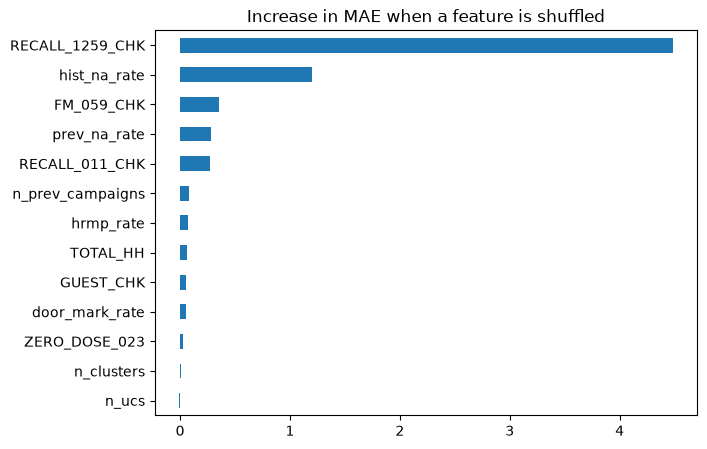

In [9]:
model = icm.make_models()[result.model_name].fit(result.train[icm.FEATURES], result.train["NA"])
imp = permutation_importance(model, result.test[icm.FEATURES], result.test["NA"],
                             scoring="neg_mean_absolute_error", n_repeats=5, random_state=42)
pd.Series(imp.importances_mean, index=icm.FEATURES).sort_values().plot.barh(
    figsize=(7, 5), title="Increase in MAE when a feature is shuffled")
plt.show()

## 6. Flagging unusual reports

The model's expected NA is compared with the reported value using a Pearson residual, rescaled by a robust
spread estimate because the counts vary more than a Poisson model assumes. Monitors beyond ±3 are flagged for review.

In [10]:
flags = icm.flag_unusual_reports(result.test, result.test["Predicted_NA"].to_numpy())
print(flags["Flag"].replace("", "Not flagged").value_counts())
flags[flags["Flag"] != ""].sort_values("Anomaly_score", ascending=False).head(10)

Flag
Not flagged             1407
Higher than expected      13
Name: count, dtype: int64


,MONITORID,CAMP_ID,campaign_start,NA,Predicted_NA,Difference,Anomaly_score,Flag
9968,506,31,2023-11-27,26,7.600,18.400,4.420,Higher than expected
9895,263,31,2023-11-27,50,20.900,29.100,4.240,Higher than expected
10872,666,34,2024-04-29,35,12.800,22.200,4.140,Higher than expected
10491,255,33,2024-03-03,54,24.200,29.800,4.030,Higher than expected
9938,403,31,2023-11-27,32,12.000,20.000,3.840,Higher than expected
10567,506,33,2024-03-04,28,10.400,17.600,3.630,Higher than expected
10532,366,33,2024-03-03,43,19.400,23.600,3.560,Higher than expected
10472,203,33,2024-03-03,46,22.100,23.900,3.380,Higher than expected
9730,761,30,2023-10-30,23,8.400,14.600,3.370,Higher than expected
10178,216,32,2024-01-08,31,12.900,18.100,3.360,Higher than expected


## 7. Conclusions

- The original R² of 0.94 came from an accounting identity, not from learning. Removing the leaky columns and
  testing on future campaigns gives a realistic **R² ≈ 0.62 / MAE ≈ 4.9 children**, compared with R² ≈ 0.42 / MAE ≈ 6.2 for the baseline.
- A monitor's **NA history** is the most useful signal after workload: some areas consistently have more children away from home.
- The anomaly score gives supervisors a short list of reports to review, rather than a single "percentage loss" number.

**Limitations and next steps:** the monitor is used as a proxy for the area they cover. Area-level history
(`UCID`), seasonality, and campaign type would probably improve the forecasts. The anomaly threshold should
be set together with the programme team, based on how many reports they can realistically review.